# Third experiment: Multiclass classification after a PCA

Application of PCA while retaining enough dimensions to preserve 95% of the variance, in order to determine the minimum number of features required to identify the samples. Additionally, PCA enables visualization of hyperspectral data in 2D and 3D spaces. Afterwards, the classification models are executed and their performance is evaluated.

## Import all libraries use

In [1]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Import dataset

The dataset with substrate is use in order to visualize the complete dataset in 2D and 3D dimension

In [3]:
def load_data():
    data = loadmat('dataset.mat')

    X_train = data['X_train']
    y_train = data['y_train'].ravel()

    X_test = data['X_test']
    y_test = data['y_test'].ravel()

    return X_train, y_train, X_test, y_test

#X variables are the pixels and Y variables are the labels
X_train, y_train, X_test, y_test = load_data()

print("Train X:", X_train.shape)
print("Train y:", y_train.shape)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (43507, 121)
Train y: (43507,)
Test X: (10809, 121)
Test y: (10809,)


In [ ]:
# Each label correspond to a material. I will name it in spanish 
class_names = {
    12: "Sustrato Algodón-lino",
    62: "Esmalte-GA",
    63: "Lapislázuli-GA",
    64: "BlancoPb-GA",
    65: "Calcita-GA",
    85: "Esmalte-CH",
    87: "BlancoPb-CH",
    88: "Calcita-CH",
    109: "Imperial Yellow Ink-GA",
    117: "Azafrán-GA",
}

In [5]:
colors = np.array([
    [0.545, 0.353, 0.235],      #marron
    [0.8500, 0.3250, 0.0980],  # naranja
    [0.0000, 0.6000, 0.5000],  # verde azulado
    [0.4940, 0.1840, 0.5560],  # morado
    [0.2500, 0.2500, 0.2500],  # gris oscuro
    [0.95, 0.6, 0.3],           #naranja claro
    [0.7, 0.5, 0.9],            # morado claro
    [0.7, 0.7, 0.7],           # gris claro
    [0.9290, 0.6940, 0.1250],  # amarillo
    [0.0000, 0.4470, 0.7410],  # azul
])

## Variance explained ratio

In [8]:
# Here is important to scale
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
pca = PCA()
pca.fit(X_train)

var_exp = pca.explained_variance_ratio_

print(var_exp[:20])

var_exp_acum = np.cumsum(var_exp[:20])

[0.45279172 0.09892721 0.06298865 0.02246495 0.0132724  0.01310215
 0.0124853  0.01210149 0.01110244 0.01076833 0.01055569 0.01045801
 0.01027799 0.00998658 0.00967055 0.00929663 0.00906308 0.0090153
 0.00871735 0.00859165]


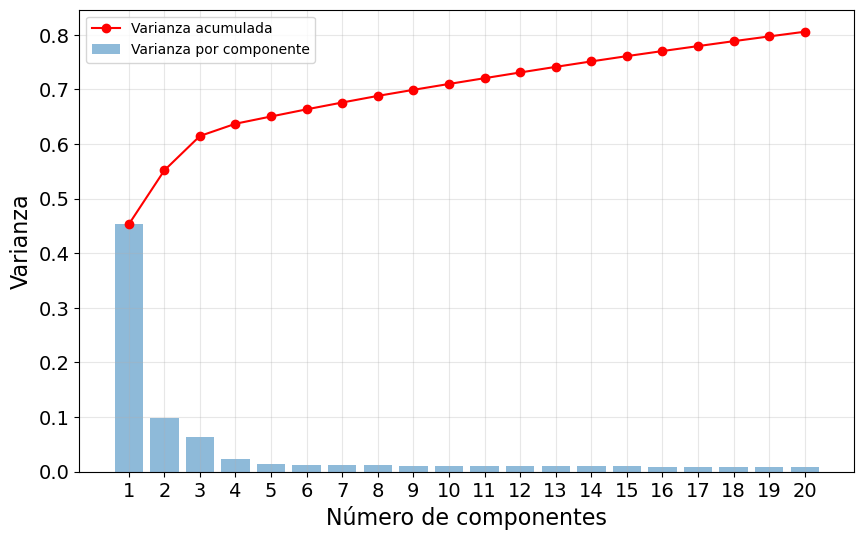

In [11]:
plt.figure(figsize=(10, 6))

plt.bar(range(1, len(var_exp[:20])+1), var_exp[:20], alpha=0.5, align='center', label='Varianza por componente')

plt.plot(range(1, len(var_exp[:20])+1), var_exp_acum,'r-o', label='Varianza acumulada')

plt.xlabel("Número de componentes", fontsize=16)
plt.ylabel("Varianza", fontsize=16)
plt.xticks(range(1, len(var_exp[:20])+1), fontsize=14)
plt.yticks(fontsize=14)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Data visualisation

In [12]:
pca2D = PCA(n_components=2)

X_train_pca = pca2D.fit_transform(X_train)
X_test_pca = pca2D.transform(X_test)

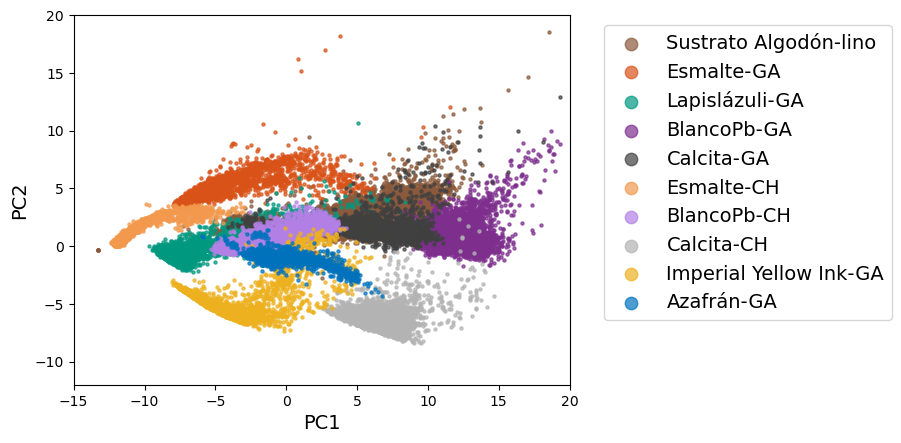

In [15]:
clases_unicas = np.unique(y_train)
color_map = {clase: colors[i] for i, clase in enumerate(clases_unicas)}

plt.figure()

for clase in clases_unicas:
    idx = y_train == clase
    plt.scatter(
        X_train_pca[idx, 0],
        X_train_pca[idx, 1],
        color=color_map[clase],
        label=class_names.get(clase, str(clase)),
        s=5,
        alpha=0.7
    )

plt.xlim(-15,20)
plt.ylim(-12,20)
plt.xlabel("PC1", fontsize=14)
plt.ylabel("PC2", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, markerscale=4)

plt.show()

In [16]:
pca_3d = PCA(n_components=3)

X_train_pca = pca_3d.fit_transform(X_train)
X_test_pca = pca_3d.transform(X_test)

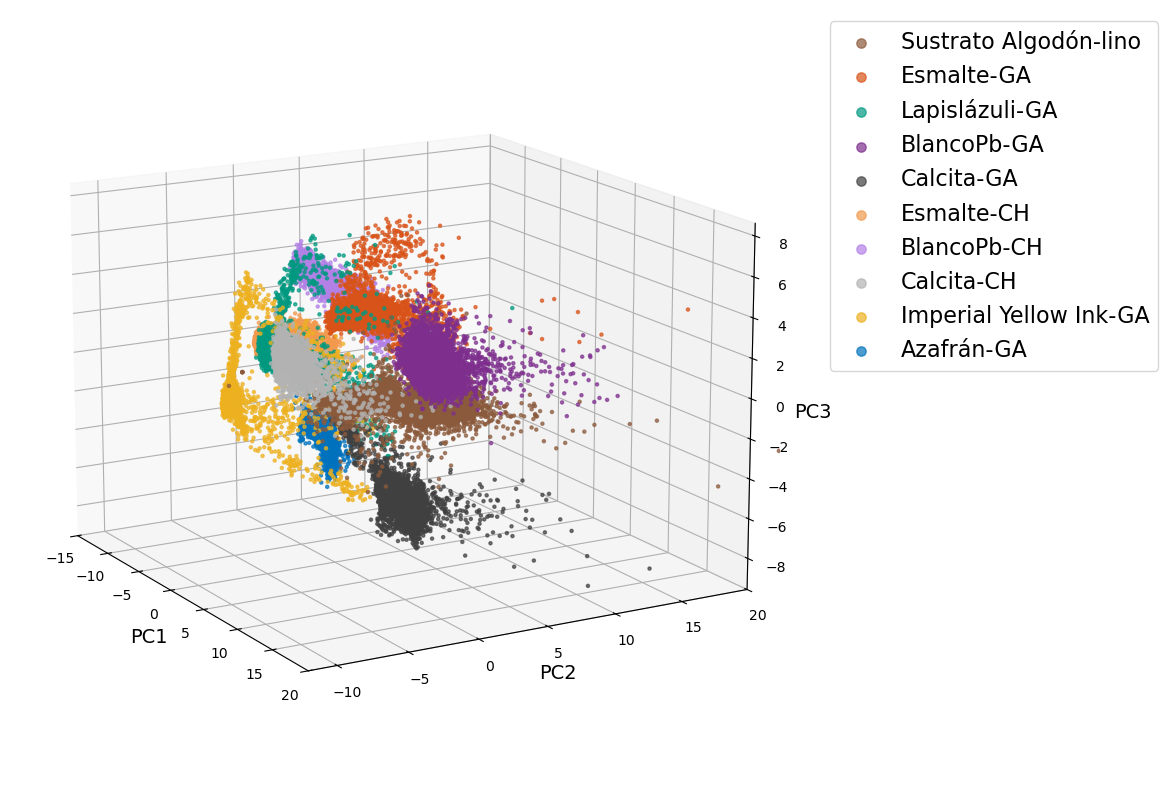

In [17]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for clase in clases_unicas:
    idx = y_train == clase
    ax.scatter(
        X_train_pca[idx, 0],
        X_train_pca[idx, 1],
        X_train_pca[idx, 2],
        color=color_map[clase],
        label=class_names.get(clase, str(clase)),
        s=5,
        alpha=0.7
    )

ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.set_zlabel("PC3", fontsize=14)
plt.xlim(-15,20)
plt.ylim(-12,20)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=16,
    markerscale=3
)
ax.view_init(elev=15, azim=-30)
plt.tight_layout()
plt.show()

## Aplication of PCA preprocessing to classify materials

Firstly, a binarization is done, so we classify the substrate

In [18]:
def load_data():
    data = loadmat('dataset_without_substrate.mat')

    X_train = data['X_train']
    y_train = data['y_train'].ravel()

    X_test = data['X_test']
    y_test = data['y_test'].ravel()

    return X_train, y_train, X_test, y_test

#X variables are the pixels and Y variables are the labels
X_train, y_train, X_test, y_test = load_data()

print("Train X:", X_train.shape)
print("Train y:", y_train.shape)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (39507, 121)
Train y: (39507,)
Test X: (9809, 121)
Test y: (9809,)


In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
pca = PCA(n_components=0.95)  #preserve 95% of the variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [21]:
print("Número de componentes:", pca.n_components_)

Número de componentes: 40


In [22]:
print("Proporción de varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)
print("Varianza explicada acumulada:")
print(pca.explained_variance_ratio_.cumsum())

Proporción de varianza explicada por cada componente:
[0.45168626 0.10055332 0.06510749 0.02133325 0.01324778 0.01316789
 0.01249916 0.01202878 0.01106714 0.01077685 0.01055293 0.01049012
 0.01031554 0.00999292 0.00970202 0.00930642 0.00912028 0.00900728
 0.00871107 0.0085922  0.00848836 0.008347   0.0082694  0.00820853
 0.00809016 0.00804682 0.00789833 0.00763118 0.00752788 0.00734401
 0.00726989 0.00722863 0.00693671 0.00668697 0.00647556 0.00615994
 0.00607325 0.00595217 0.00590346 0.0057822 ]
Varianza explicada acumulada:
[0.45168626 0.5522396  0.61734706 0.63868034 0.6519281  0.66509604
 0.6775952  0.68962395 0.7006911  0.711468   0.7220209  0.73251104
 0.7428266  0.7528195  0.7625215  0.77182794 0.7809482  0.7899555
 0.79866654 0.8072587  0.8157471  0.82409406 0.8323635  0.840572
 0.84866214 0.85670894 0.8646073  0.87223846 0.87976635 0.88711035
 0.8943803  0.9016089  0.9085456  0.9152326  0.92170817 0.9278681
 0.93394136 0.93989354 0.945797   0.9515792 ]


### Scores of each component

Lets visualize the score of three first principal component, so we can see the bands that are important.

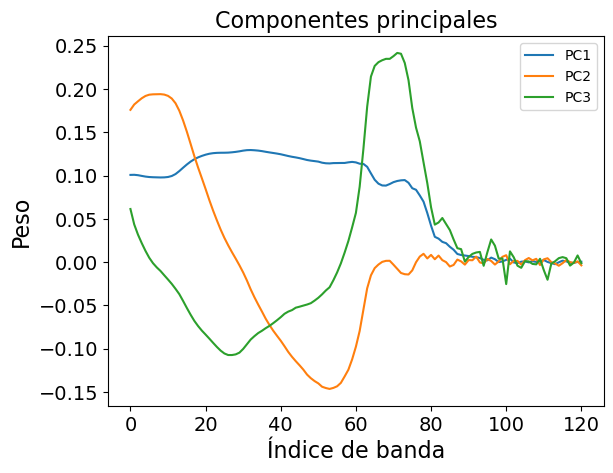

In [25]:
plt.plot(pca.components_[0], label="PC1")
plt.plot(pca.components_[1], label="PC2")
plt.plot(pca.components_[2], label="PC3")

plt.title("Componentes principales", fontsize=16)
plt.xlabel("Índice de banda", fontsize=16)
plt.ylabel("Peso", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend()
plt.show()

## SVM classification with reduction of dimensionality

In [26]:
from sklearn.svm import SVC # SVM
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay # métricas de evaluación

In [27]:
svm_model = SVC(kernel="rbf", C=10, gamma="scale")
svm_model.fit(X_train_pca, y_train)
y_pred_svm = svm_model.predict(X_test_pca)

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification report:")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7545111632174534

Classification report:
              precision    recall  f1-score   support

          62       0.98      0.97      0.98       856
          63       0.57      0.73      0.64       803
          64       0.65      0.93      0.77       792
          65       0.80      1.00      0.89       364
          85       0.98      0.99      0.99       334
          87       0.98      0.60      0.74      1001
          88       0.96      0.58      0.72      2975
         109       0.62      0.80      0.70      2094
         117       0.63      0.96      0.76       590

    accuracy                           0.75      9809
   macro avg       0.80      0.84      0.80      9809
weighted avg       0.81      0.75      0.75      9809



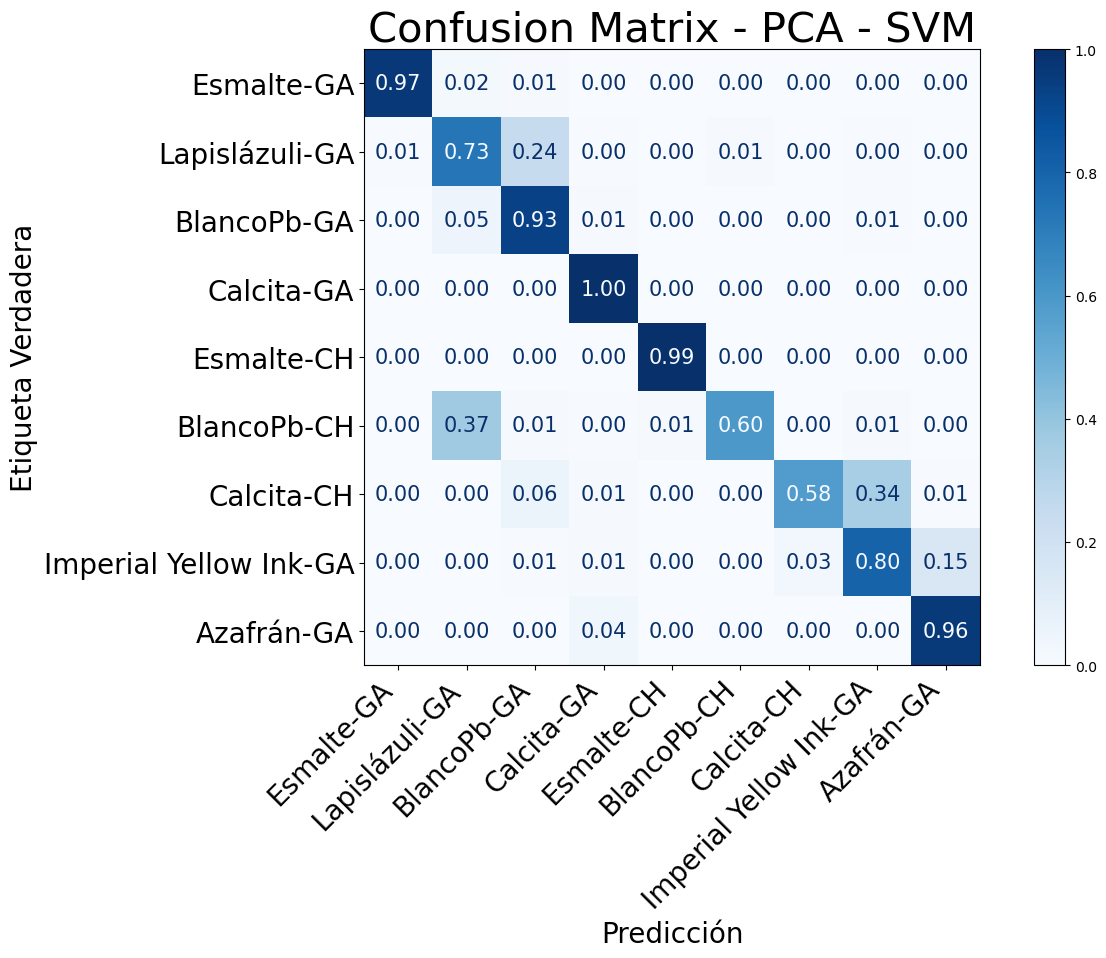

In [31]:
labels = list(class_names.keys())
display_labels = [class_names[l] for l in labels]

fig, ax = plt.subplots(figsize=(14,8))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - PCA - SVM", fontsize=30)

# reducimos tamaño del texto dentro de las celdas
for text in ax.texts:
    text.set_fontsize(15)

ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=20)
ax.set_yticklabels(display_labels, rotation=0, fontsize=20)

ax.set_xlabel("Predicción", fontsize=20)
ax.set_ylabel("Etiqueta Verdadera", fontsize=20)

plt.show()